In [21]:
import os
import
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import img_to_array
from sklearn.model_selection import train_test_split # To split training data for autoencoder validation

# --- Configuration ---
# Adjust BASE_PATH if your notebook is in a different location relative to 'soil_competition-2025'
# Assuming 'soil_detection.ipynb' is in 'soil_01' and 'soil_competition-2025' is a subfolder
BASE_PATH = 'soil_competition-2025'
TRAIN_IMAGE_DIR = os.path.join(BASE_PATH, 'train')
TEST_IMAGE_DIR = os.path.join(BASE_PATH, 'test') # Assuming test images are in the 'test' folder

TRAIN_LABELS_FILE = os.path.join(BASE_PATH, 'train_labels.csv')
TEST_IDS_FILE = os.path.join(BASE_PATH, 'test_ids.csv')
SAMPLE_SUBMISSION_FILE = os.path.join(BASE_PATH, 'sample_submission.csv')

IMG_WIDTH = 128  # You can experiment with image size
IMG_HEIGHT = 128
CHANNELS = 3     # Assuming RGB images
IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)

BATCH_SIZE = 32
EPOCHS = 50      # Adjust based on your dataset size and computational resources

In [22]:
def load_and_preprocess_image(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    """Loads an image, resizes it, converts to array, and normalizes."""
    try:
        img = Image.open(image_path).convert('RGB') # Ensure image is RGB
        img = img.resize(target_size)
        img_array = img_to_array(img)
        img_array = img_array / 255.0  # Normalize to [0, 1]
        return img_array
    except FileNotFoundError:
        print(f"Warning: Image not found at {image_path}")
        return None
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

# Load training data (only soil images)
train_df = pd.read_csv(TRAIN_LABELS_FILE)

# Since all training labels are 1, we just need the image_id list for soil images
# If there were other labels, we would filter: soil_images_df = train_df[train_df['label'] == 1]
soil_image_ids = train_df['image_id'].tolist()
train_image_paths = [os.path.join(TRAIN_IMAGE_DIR, fname) for fname in soil_image_ids]

print(f"Total training (soil) images found: {len(train_image_paths)}")

# Load and preprocess all training images
X_train_full = []
for path in train_image_paths:
    img = load_and_preprocess_image(path)
    if img is not None:
        X_train_full.append(img)

if not X_train_full:
    raise ValueError("No training images were loaded. Please check TRAIN_IMAGE_DIR and image files.")

X_train_full = np.array(X_train_full)
print(f"Shape of loaded training images: {X_train_full.shape}")

# Split training data into training and validation sets for the autoencoder
# This helps monitor the autoencoder's learning process on unseen (but still soil) images
if len(X_train_full) > 1:
    X_train, X_val = train_test_split(X_train_full, test_size=0.2, random_state=42)
    print(f"Autoencoder training set shape: {X_train.shape}")
    print(f"Autoencoder validation set shape: {X_val.shape}")
else:
    X_train = X_train_full
    X_val = X_train_full # Use same data if very few images
    print(f"Very few images, using the same data for training and validation: {X_train.shape}")

Total training (soil) images found: 1222
Shape of loaded training images: (1222, 128, 128, 3)
Autoencoder training set shape: (977, 128, 128, 3)
Autoencoder validation set shape: (245, 128, 128, 3)


In [23]:
def build_autoencoder(input_shape):
    # Encoder
    input_img = Input(shape=input_shape)
    # Level 1
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    # Level 2
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    # Level 3 (Latent Space)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x) # Shape: (height/8, width/8, 128)

    # Decoder
    # Level 3
    x = Conv2DTranspose(128, (3,3), strides=2, activation='relu', padding='same')(encoded)
    # Level 2
    x = Conv2DTranspose(64, (3,3), strides=2, activation='relu', padding='same')(x)
    # Level 1
    x = Conv2DTranspose(32, (3,3), strides=2, activation='relu', padding='same')(x)
    decoded = Conv2D(input_shape[-1], (3, 3), activation='sigmoid', padding='same')(x) # Output layer, sigmoid for [0,1]

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer=Adam(learning_rate=1e-3), loss='mse') # MSE for reconstruction loss
    return autoencoder

autoencoder_model = build_autoencoder(IMG_SHAPE)
autoencoder_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 32, 32, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 64, 64, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 128, 128, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

Starting autoencoder training...
Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 25s 681ms/step - loss: 0.0704 - val_loss: 0.0550
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 656ms/step - loss: 0.0382 - val_loss: 0.0195
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 628ms/step - loss: 0.0171 - val_loss: 0.0132
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 633ms/step - loss: 0.0104 - val_loss: 0.0101
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 645ms/step - loss: 0.0095 - val_loss: 0.0096
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 608ms/step - loss: 0.0085 - val_loss: 0.0085
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 631ms/step - loss: 0.0077 - val_loss: 0.0081
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 642ms/step - loss: 0.0073 - val_loss: 0.0078
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 631ms/step - loss: 0.0072 - val_loss: 0.0079
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 640ms/step - loss: 0.0067 - val_loss: 0.0074
Epoch 11/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 667ms/step - loss: 0.0071 - val_loss: 0.0075
Epoch 12

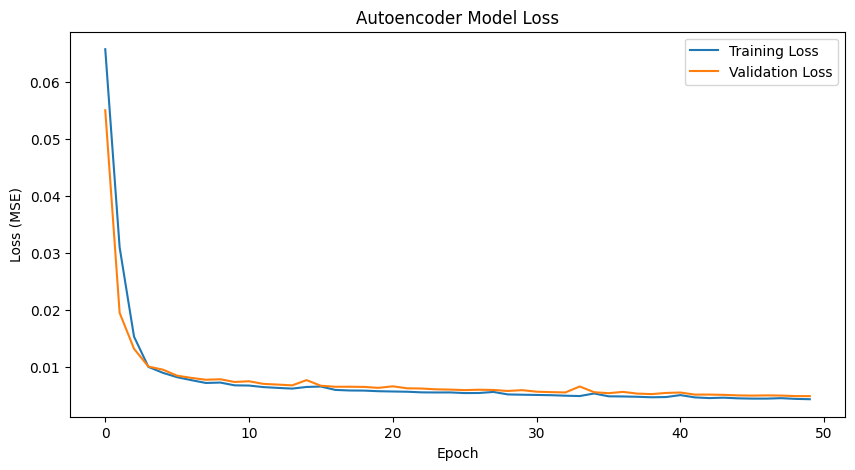

In [24]:
if X_train.shape[0] == 0:
    print("No data available for training the autoencoder. Please check data loading.")
else:
    print("Starting autoencoder training...")
    history = autoencoder_model.fit(
        X_train, X_train,  # Input and target are the same for autoencoders
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        validation_data=(X_val, X_val) # Validate on soil images not seen during epoch training
    )

    # Plot training & validation loss values
    if history:
        plt.figure(figsize=(10, 5))
        plt.plot(history.history['loss'], label='Training Loss')
        if 'val_loss' in history.history:
            plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title('Autoencoder Model Loss')
        plt.ylabel('Loss (MSE)')
        plt.xlabel('Epoch')
        plt.legend(loc='upper right')
        plt.show()

31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step
Calculated Reconstruction Error Threshold: 0.011925882659852505


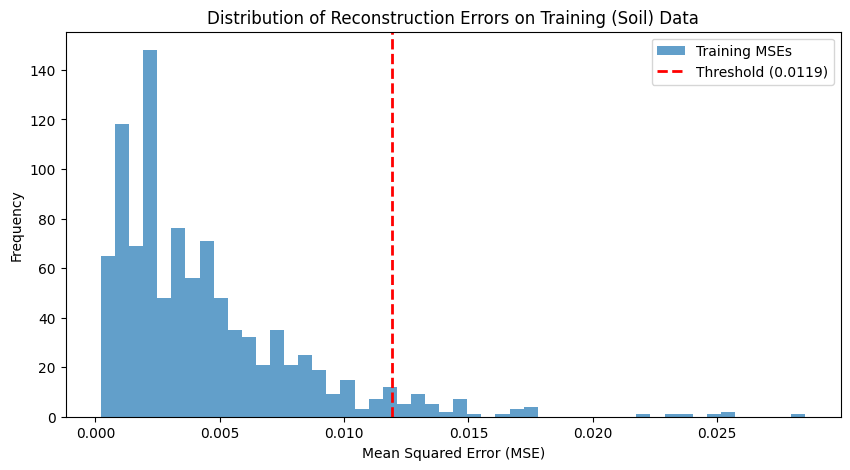

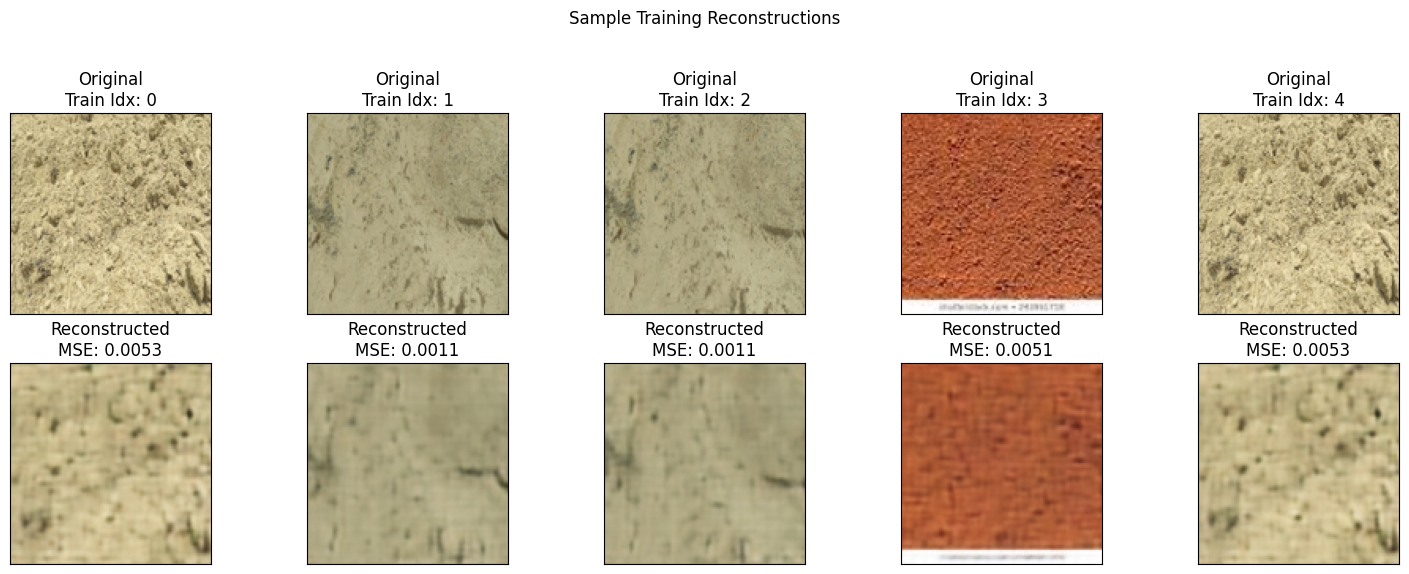

In [25]:
# Calculate reconstruction errors on the (soil) training data
if X_train.shape[0] > 0:
    reconstructed_train_images = autoencoder_model.predict(X_train)
    # Calculate Mean Squared Error for each image
    train_mse = np.mean(np.power(X_train - reconstructed_train_images, 2), axis=(1, 2, 3))

    # Determine threshold: e.g., mean + k * std_dev, or a percentile
    # Using a percentile (e.g., 95th) can be robust
    threshold = np.percentile(train_mse, 95)
    # Alternative: threshold = np.mean(train_mse) + 2 * np.std(train_mse)
    print(f"Calculated Reconstruction Error Threshold: {threshold}")

    # Plot histogram of training reconstruction errors
    plt.figure(figsize=(10, 5))
    plt.hist(train_mse, bins=50, alpha=0.7, label='Training MSEs')
    plt.axvline(threshold, color='r', linestyle='dashed', linewidth=2, label=f'Threshold ({threshold:.4f})')
    plt.title('Distribution of Reconstruction Errors on Training (Soil) Data')
    plt.xlabel('Mean Squared Error (MSE)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

    # Visualize some original vs. reconstructed training images
    n_examples = min(5, len(X_train))
    if n_examples > 0:
        plt.figure(figsize=(15, 6))
        for i in range(n_examples):
            # Display original
            ax = plt.subplot(2, n_examples, i + 1)
            plt.imshow(X_train[i])
            plt.title(f"Original\nTrain Idx: {i}")
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)

            # Display reconstruction
            ax = plt.subplot(2, n_examples, i + 1 + n_examples)
            plt.imshow(reconstructed_train_images[i])
            plt.title(f"Reconstructed\nMSE: {train_mse[i]:.4f}")
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
        plt.suptitle("Sample Training Reconstructions")
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
        plt.show()
else:
    print("Not enough training data to calculate threshold. Using a default.")
    threshold = 0.01 # Arbitrary default, adjust if needed or ensure training data loads


Making predictions on 967 test images...

Submission file 'submission.csv' created.
                               image_id  label
0  6595f1266325552489c7d1635fafb88f.jpg      1
1  4b614841803d5448b59e2c6ca74ea664.jpg      1
2  ca30e008692a50638b43d944f46245c8.jpg      0
3  6a9046a219425f7599729be627df1c1a.jpg      0
4  97c1e0276d2d5c2f88dddbc87357611e.jpg      1

Predicted as soil: 937 / 967


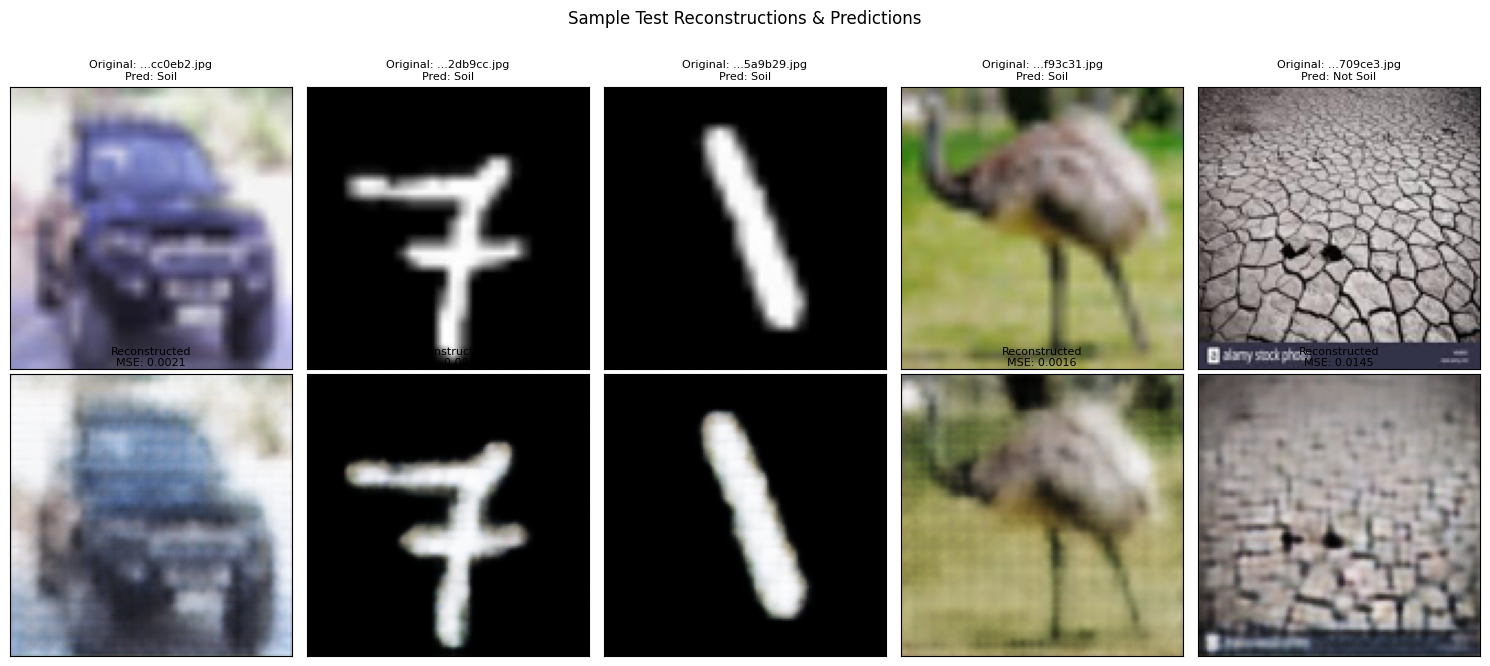

In [26]:
# Load test image IDs
test_ids_df = pd.read_csv(TEST_IDS_FILE)
test_image_ids = test_ids_df['image_id'].tolist()

predictions = []
processed_test_image_ids = [] # To keep track of images we actually made predictions for

print(f"\nMaking predictions on {len(test_image_ids)} test images...")
for image_id in test_image_ids:
    image_path = os.path.join(TEST_IMAGE_DIR, image_id)
    test_img = load_and_preprocess_image(image_path)

    if test_img is not None:
        img_batch = np.expand_dims(test_img, axis=0) # Model expects batch dimension
        reconstructed_img = autoencoder_model.predict(img_batch, verbose=0)
        mse = np.mean(np.power(img_batch - reconstructed_img, 2))

        if mse > threshold:
            label = 0  # Not soil (anomaly)
        else:
            label = 1  # Soil (normal)
        predictions.append({'image_id': image_id, 'label': label})
        processed_test_image_ids.append(image_id)
    else:
        print(f"Warning: Test image {image_id} could not be loaded. Assigning default label 0 (not soil).")
        # Decide how to handle missing/corrupt test images, e.g., predict 0 or skip
        predictions.append({'image_id': image_id, 'label': 0})


# Create submission DataFrame
submission_df = pd.DataFrame(predictions)

# Ensure the order of columns matches sample_submission.csv
try:
    sample_sub_df = pd.read_csv(SAMPLE_SUBMISSION_FILE)
    submission_df = submission_df[sample_sub_df.columns]
except FileNotFoundError:
    print(f"Warning: {SAMPLE_SUBMISSION_FILE} not found. Submission file will have default column order.")
except KeyError:
    print(f"Warning: Columns in sample_submission.csv do not match 'image_id', 'label'. Submission file will have default column order.")


submission_df.to_csv('submission.csv', index=False)
print("\nSubmission file 'submission.csv' created.")
print(submission_df.head())
print(f"\nPredicted as soil: {submission_df['label'].sum()} / {len(submission_df)}")


# (Optional) Visualize some test images, their reconstructions, and predictions
n_test_examples_to_show = min(5, len(processed_test_image_ids))
if n_test_examples_to_show > 0:
    plt.figure(figsize=(15, 7)) # Increased height for more text

    # Select a few images that were successfully processed for visualization
    image_ids_to_show = np.random.choice(processed_test_image_ids, n_test_examples_to_show, replace=False)

    for i, img_id_to_show in enumerate(image_ids_to_show):
        path_to_show = os.path.join(TEST_IMAGE_DIR, img_id_to_show)
        original_test_img = load_and_preprocess_image(path_to_show)

        if original_test_img is not None:
            img_batch = np.expand_dims(original_test_img, axis=0)
            reconstructed_test_img_arr = autoencoder_model.predict(img_batch, verbose=0)
            reconstructed_test_img = reconstructed_test_img_arr[0] # Get the image from the batch

            current_mse = np.mean(np.power(original_test_img - reconstructed_test_img, 2))
            predicted_label = submission_df[submission_df['image_id'] == img_id_to_show]['label'].iloc[0]

            # Original
            ax = plt.subplot(2, n_test_examples_to_show, i + 1)
            plt.imshow(original_test_img)
            plt.title(f"Original: ...{img_id_to_show[-10:]}\nPred: {'Soil' if predicted_label == 1 else 'Not Soil'}", fontsize=8)
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)

            # Reconstructed
            ax = plt.subplot(2, n_test_examples_to_show, i + 1 + n_test_examples_to_show)
            plt.imshow(reconstructed_test_img)
            plt.title(f"Reconstructed\nMSE: {current_mse:.4f}", fontsize=8)
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)

    plt.suptitle("Sample Test Reconstructions & Predictions", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

In [27]:
# --- Section 7: Save the Trained Autoencoder Model ---

MODEL_SAVE_PATH = 'soil_detection_autoencoder.h5' # Keras H5 format
# For TensorFlow SavedModel format:
# MODEL_SAVE_PATH = 'soil_detection_autoencoder_model_tf'

if autoencoder_model:
    autoencoder_model.save(MODEL_SAVE_PATH)
    print(f"\nTrained autoencoder model saved to: {MODEL_SAVE_PATH}")

    # To load the model later:
    # from tensorflow.keras.models import load_model
    # loaded_model = load_model(MODEL_SAVE_PATH)
    # print("Model loaded successfully.")
else:
    print("\nAutoencoder model is not trained or available to save.")


Trained autoencoder model saved to: soil_detection_autoencoder.h5


In [28]:
# --- Simplified Metrics for X_val (where all y_true_val are 1) ---
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

print("\n--- Simplified Metrics based ONLY on X_val (all true labels are '1' - Soil) ---")

if 'X_val' in globals() and X_val.shape[0] > 0 and 'threshold' in globals():
    # Re-predict on X_val if not already done or to ensure variables are in scope
    reconstructed_val_images = autoencoder_model.predict(X_val, verbose=0) # verbose=0 to suppress progress bar
    val_mse = np.mean(np.power(X_val - reconstructed_val_images, 2), axis=(1, 2, 3))
    y_pred_val = (val_mse <= threshold).astype(int) # 1 if soil, 0 if not soil
    y_true_val = np.ones(len(X_val), dtype=int)    # All true labels are 1

    # Accuracy (how many of X_val soil images were predicted correctly as soil)
    # This is identical to what we calculated before
    acc_val_soil = accuracy_score(y_true_val, y_pred_val)
    print(f"Accuracy (on X_val, how many soil images predicted as soil): {acc_val_soil:.4f}")

    # For F1-score, precision, and recall, we need to specify pos_label=1
    # because y_true_val only contains label 1.
    # If we don't, and y_pred_val happens to be all 1s, it might average weirdly or warn.

    # Precision for class '1' (Soil) on X_val:
    # TP_soil / (TP_soil + FP_soil)
    # Since y_true_val has no '0's, any '0' predicted by the model is an FN for soil.
    # Any '1' predicted by the model is a TP for soil (because all true are '1').
    # There are no "true '0's" in y_true_val, so FP_soil (predicting '1' when true is '0') cannot be determined from X_val.
    # sklearn will calculate precision for label '1' as:
    # (number of items correctly predicted as '1') / (total number of items predicted as '1')
    precision_val_soil = precision_score(y_true_val, y_pred_val, pos_label=1, zero_division=0)
    print(f"Precision for 'Soil' class (on X_val): {precision_val_soil:.4f}")


    # Recall for class '1' (Soil) on X_val:
    # TP_soil / (TP_soil + FN_soil)
    # This is (number of items correctly predicted as '1') / (total number of items that are truly '1')
    # This is identical to acc_val_soil in this specific scenario.
    recall_val_soil = recall_score(y_true_val, y_pred_val, pos_label=1, zero_division=0)
    print(f"Recall for 'Soil' class (on X_val): {recall_val_soil:.4f}")

    # F1-score for class '1' (Soil) on X_val:
    # 2 * (Precision_soil * Recall_soil) / (Precision_soil + Recall_soil)
    f1_val_soil = f1_score(y_true_val, y_pred_val, pos_label=1, zero_division=0)
    print(f"F1-score for 'Soil' class (on X_val): {f1_val_soil:.4f}")

    print("\nREMINDER: These metrics are calculated considering ONLY the 'soil' images in X_val.")
    print("They primarily reflect how well the model identifies known soil images as 'soil'.")
    print("They DO NOT reflect how well the model distinguishes 'soil' from 'not soil' in a mixed dataset.")

else:
    print("X_val or threshold not available for this simplified calculation.")


--- Simplified Metrics based ONLY on X_val (all true labels are '1' - Soil) ---
Accuracy (on X_val, how many soil images predicted as soil): 0.9020
Precision for 'Soil' class (on X_val): 1.0000
Recall for 'Soil' class (on X_val): 0.9020
F1-score for 'Soil' class (on X_val): 0.9485

REMINDER: These metrics are calculated considering ONLY the 'soil' images in X_val.
They primarily reflect how well the model identifies known soil images as 'soil'.
They DO NOT reflect how well the model distinguishes 'soil' from 'not soil' in a mixed dataset.
